Setup & Config

In [8]:
# ── Force re-extract and debug ───────────────────────────────────────────────
import os, zipfile, shutil

CLEANED_ZIP  = '/content/drive/MyDrive/cleaned_dataset.zip'  # ✏️ your zip path
CLEANED_PATH = '/content/cleaned_dataset_extracted'

# Delete the empty folder and re-extract
shutil.rmtree(CLEANED_PATH, ignore_errors=True)
os.makedirs(CLEANED_PATH, exist_ok=True)

# Check zip exists and its size
if not os.path.exists(CLEANED_ZIP):
    print(f"❌ Zip not found at: {CLEANED_ZIP}")
    print("\n📂 Files in your MyDrive root:")
    for f in os.listdir('/content/drive/MyDrive/'):
        print(f"   {f}")
else:
    size_mb = os.path.getsize(CLEANED_ZIP) / (1024 * 1024)
    print(f"✅ Zip found — Size: {size_mb:.2f} MB")

    # Peek inside zip before extracting
    with zipfile.ZipFile(CLEANED_ZIP, 'r') as z:
        all_files = z.namelist()
        print(f"📄 Total items inside zip: {len(all_files)}")
        print(f"\n📂 First 20 entries inside zip:")
        for f in all_files[:20]:
            print(f"   {f}")

    # Re-extract
    print(f"\n📦 Re-extracting...")
    with zipfile.ZipFile(CLEANED_ZIP, 'r') as z:
        z.extractall(CLEANED_PATH)
    print(f"✅ Done! Re-extracted to {CLEANED_PATH}")

    # Verify
    total = sum(len(files) for _, _, files in os.walk(CLEANED_PATH))
    print(f"📁 Total files after extraction: {total}")

✅ Zip found — Size: 2512.41 MB
📄 Total items inside zip: 5230

📂 First 20 entries inside zip:
   blast/Blast_0981.jpg
   blast/Blast_1106.jpg
   blast/Blast_1296.jpg
   blast/Blast_0084.jpeg
   blast/Blast_2205.jpg
   blast/Blast_1671.jpg
   blast/Blast_2528.jpg
   blast/Blast_2417.jpg
   blast/Blast_1861.jpeg
   blast/Blast_2246.jpg
   blast/Blast_2270.jpg
   blast/Blast_0503.jpeg
   blast/Blast_0710.jpeg
   blast/Blast_1538.jpg
   blast/Blast_1747.jpg
   blast/Blast_2290.jpg
   blast/Blast_1196.jpg
   blast/Blast_1948.jpeg
   blast/Blast_0848.jpeg
   blast/Blast_1422.jpg

📦 Re-extracting...
✅ Done! Re-extracted to /content/cleaned_dataset_extracted
📁 Total files after extraction: 5230


In [10]:
import os, shutil, zipfile
from collections import defaultdict
from PIL import Image
import numpy as np
import cv2
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

# ── Paths ────────────────────────────────────────────────────────────────────
CLEANED_ZIP    = '/content/drive/MyDrive/cleaned_dataset.zip'   # ✏️ Phase A output zip
CLEANED_PATH   = '/content/cleaned_dataset_extracted'
ENHANCED_PATH  = '/content/enhanced_dataset'
AB_TEST_PATH   = '/content/bg_removal_ab_test'
LOG_PATH       = '/content/phase_b_logs'

CLASSES_KEEP   = ['blast', 'bacterial_leaf_blight', 'brown_spot']  # ✏️ your classes

VALID_EXTS = (
    '.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp',
    '.JPG', '.JPEG', '.PNG', '.BMP', '.TIFF', '.WEBP'
)

# ── Extract zip if not already done ─────────────────────────────────────────
if not os.path.exists(CLEANED_PATH):
    print(f"📦 Extracting {CLEANED_ZIP} ...")
    os.makedirs(CLEANED_PATH, exist_ok=True)
    with zipfile.ZipFile(CLEANED_ZIP, 'r') as z:
        z.extractall(CLEANED_PATH)
    print(f"✅ Extracted to {CLEANED_PATH}")
else:
    print(f"⏭️  Already extracted — skipping.")

for p in [ENHANCED_PATH, AB_TEST_PATH, LOG_PATH]:
    os.makedirs(p, exist_ok=True)

# ── Helper: collect all images into a flat list ───────────────────────────────
def get_all_images(root_path, keep_classes=None):
    entries = []
    for dirpath, _, filenames in os.walk(root_path):
        cls = os.path.basename(dirpath)
        if keep_classes and cls not in keep_classes:
            continue
        for fname in filenames:
            if fname.lower().endswith(
                tuple(e.lower() for e in VALID_EXTS)
            ):
                entries.append((cls, fname, os.path.join(dirpath, fname)))
    return entries

entries = get_all_images(CLEANED_PATH, keep_classes=CLASSES_KEEP)
print(f"\n📁 Found {len(entries)} images across {CLASSES_KEEP}")

# ── Sanity check ─────────────────────────────────────────────────────────────
if len(entries) == 0:
    print("⚠️  No images found. Actual folder structure:")
    for root, dirs, _ in os.walk(CLEANED_PATH):
        depth = root.replace(CLEANED_PATH, '').count(os.sep)
        if depth < 3:
            print(f"  {'  ' * depth}{os.path.basename(root)}/")
    raise SystemExit("Fix CLEANED_PATH or CLASSES_KEEP then re-run.")

# ── Master tracking dataframe ─────────────────────────────────────────────────
master = pd.DataFrame([
    {'class': c, 'file': f, 'path': p, 'status': 'pending'}
    for c, f, p in entries
])

print(f"\n  Class counts (input to Phase B):")
for cls, cnt in master['class'].value_counts().items():
    print(f"    {cls:<30} {cnt}")
print(f"\n✅ Tracking {len(master)} images. Ready for Phase B.")

⏭️  Already extracted — skipping.

📁 Found 5230 images across ['blast', 'bacterial_leaf_blight', 'brown_spot']

  Class counts (input to Phase B):
    blast                          2760
    brown_spot                     1392
    bacterial_leaf_blight          1078

✅ Tracking 5230 images. Ready for Phase B.


CLAHE on L-channel

  STEP B2 — CLAHE (Lesion Contrast Enhancement)


/tmp/ipykernel_891/1573625297.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


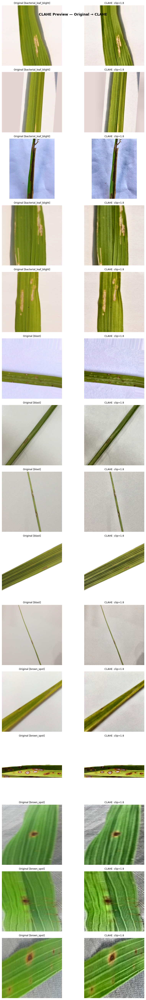


✏️ CLAHE Tuning Guide

Current Settings
----------------
clipLimit     = 1.8
tileGridSize  = (8, 8)

Interpretation
--------------
✅ Lesions become clearer and easier to distinguish
✅ Disease boundaries become sharper
✅ Leaf texture becomes more visible

Adjustments
-----------
❌ Grainy / noisy appearance
    → Reduce clipLimit to 1.5

❌ Very little visible enhancement
    → Increase clipLimit to 3.0

❌ Over-enhanced textures
    → Increase tileGridSize to (16,16)

❌ Uneven local contrast
    → Try tileGridSize = (12,12)

Recommended Range
-----------------
clipLimit     : 1.5 – 3.0
tileGridSize  : (8,8) or (16,16)



In [11]:
print("=" * 60)
print("  STEP B2 — CLAHE (Lesion Contrast Enhancement)")
print("=" * 60)

sample_preview = (
    master[master['status'] == 'pending']
    .groupby('class')
    .apply(
        lambda g: g.sample(
            min(5, len(g)),
            random_state=42
        )
    )
    .reset_index(drop=True)
)

CLAHE_CLIP_LIMIT = 1.8      # try 3.0 if lesions still faint
CLAHE_GRID_SIZE  = (8, 8)   # smaller = stronger local enhancement

clahe_engine = cv2.createCLAHE(
    clipLimit=CLAHE_CLIP_LIMIT,
    tileGridSize=CLAHE_GRID_SIZE
)

def apply_clahe(img_bgr):
    """
    Apply CLAHE only on the L (lightness) channel.

    Benefits:
    - Improves lesion visibility
    - Enhances local contrast
    - Preserves disease colors
    - Avoids artificial color shifts
    """
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

    L, A, B = cv2.split(lab)

    L_eq = clahe_engine.apply(L)

    lab_eq = cv2.merge([L_eq, A, B])

    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)


# ─────────────────────────────────────────────────────────────
# Preview: Original → CLAHE
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    len(sample_preview),
    2,
    figsize=(10, 3.5 * len(sample_preview))
)

if len(sample_preview) == 1:
    axes = np.array([axes])

for i, row in sample_preview.iterrows():

    img_bgr = cv2.imread(row['path'])

    img_clahe = apply_clahe(img_bgr)

    preview_images = [
        (img_bgr,   f"Original [{row['class']}]"),
        (img_clahe, f"CLAHE  clip={CLAHE_CLIP_LIMIT}")
    ]

    for j, (img, title) in enumerate(preview_images):

        axes[i, j].imshow(
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        )

        axes[i, j].set_title(title, fontsize=9)
        axes[i, j].axis('off')

plt.suptitle(
    "CLAHE Preview — Original → CLAHE",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print(f"""
✏️ CLAHE Tuning Guide

Current Settings
----------------
clipLimit     = {CLAHE_CLIP_LIMIT}
tileGridSize  = {CLAHE_GRID_SIZE}

Interpretation
--------------
✅ Lesions become clearer and easier to distinguish
✅ Disease boundaries become sharper
✅ Leaf texture becomes more visible

Adjustments
-----------
❌ Grainy / noisy appearance
    → Reduce clipLimit to 1.5

❌ Very little visible enhancement
    → Increase clipLimit to 3.0

❌ Over-enhanced textures
    → Increase tileGridSize to (16,16)

❌ Uneven local contrast
    → Try tileGridSize = (12,12)

Recommended Range
-----------------
clipLimit     : 1.5 – 3.0
tileGridSize  : (8,8) or (16,16)
""")

Light Gaussian Denoising

  STEP B3 — Light Gaussian Denoising (3×3 kernel)


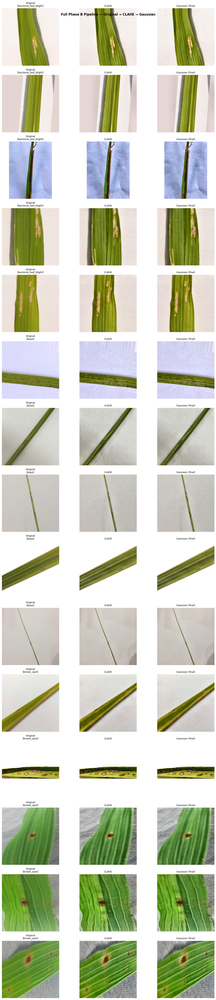


✏️ Final Visual Inspection

Current Settings
----------------
CLAHE clipLimit     : 1.8
CLAHE tileGridSize  : (8, 8)
Gaussian Kernel     : (3, 3)

Checklist
---------
✅ Lesions remain clearly visible
✅ Lesion boundaries remain sharp
✅ No noticeable color distortion
✅ No excessive smoothing
✅ Background texture not amplified
✅ No CLAHE tile artifacts visible

Expected Outcome
----------------
Column 2 (CLAHE):
    Better lesion visibility

Column 3 (Gaussian):
    Similar visibility
    Slightly cleaner texture
    Reduced local noise

If Column 3 looks cleaner than Column 2
without losing lesion detail,
Phase B preprocessing is finalized.



In [12]:
print("=" * 60)
print("  STEP B3 — Light Gaussian Denoising (3×3 kernel)")
print("=" * 60)

GAUSSIAN_KERNEL = (3, 3)

def apply_light_denoise(img_bgr):
    """
    Light Gaussian smoothing after CLAHE.

    Purpose:
    - Remove CLAHE-induced micro-noise
    - Smooth small texture artifacts
    - Preserve lesion boundaries
    - Improve stability for later segmentation
    """
    return cv2.GaussianBlur(
        img_bgr,
        GAUSSIAN_KERNEL,
        sigmaX=0,
        sigmaY=0
    )

# ─────────────────────────────────────────────────────────────
# Full Pipeline Preview
# Original → CLAHE → Gaussian
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    len(sample_preview),
    3,
    figsize=(13, 3.5 * len(sample_preview))
)

col_labels = [
    'Original',
    'CLAHE',
    'Gaussian (final)'
]

for i, row in sample_preview.iterrows():

    img_bgr = cv2.imread(row['path'])

    img_clahe = apply_clahe(img_bgr)

    img_final = apply_light_denoise(img_clahe)

    preview_images = [
        img_bgr,
        img_clahe,
        img_final
    ]

    for j, (img, title) in enumerate(
        zip(preview_images, col_labels)
    ):

        label = (
            f"{title}\n[{row['class']}]"
            if j == 0 else title
        )

        axes[i, j].imshow(
            cv2.cvtColor(
                img,
                cv2.COLOR_BGR2RGB
            )
        )

        axes[i, j].set_title(
            label,
            fontsize=9
        )

        axes[i, j].axis('off')

plt.suptitle(
    'Full Phase B Pipeline — Original → CLAHE → Gaussian',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print(f"""
✏️ Final Visual Inspection

Current Settings
----------------
CLAHE clipLimit     : {CLAHE_CLIP_LIMIT}
CLAHE tileGridSize  : {CLAHE_GRID_SIZE}
Gaussian Kernel     : {GAUSSIAN_KERNEL}

Checklist
---------
✅ Lesions remain clearly visible
✅ Lesion boundaries remain sharp
✅ No noticeable color distortion
✅ No excessive smoothing
✅ Background texture not amplified
✅ No CLAHE tile artifacts visible

Expected Outcome
----------------
Column 2 (CLAHE):
    Better lesion visibility

Column 3 (Gaussian):
    Similar visibility
    Slightly cleaner texture
    Reduced local noise

If Column 3 looks cleaner than Column 2
without losing lesion detail,
Phase B preprocessing is finalized.
""")

Run Full Pipeline & Save to Disk
Only run this after previews in Blocks 2–4 look correct. This is the only block that writes files.

In [13]:
print("=" * 60)
print("  Running Full Phase B Pipeline on All Images")
print("=" * 60)

def process_image(fpath):
    """
    Final Phase B Pipeline

    Step 1: CLAHE
    Step 2: Gaussian Denoising

    Returns:
        uint8 BGR image
        None if image cannot be read
    """

    img_bgr = cv2.imread(fpath)

    if img_bgr is None:
        return None

    # Step B2
    img = apply_clahe(img_bgr)

    # Step B3
    img = apply_light_denoise(img)

    return img


processed_count = 0
error_count     = 0
error_log       = []

for idx, row in tqdm(
    master.iterrows(),
    total=len(master),
    desc="Phase B — full run"
):

    try:

        result = process_image(row['path'])

        if result is None:

            master.at[idx, 'status'] = 'error: unreadable'

            error_count += 1

            error_log.append({
                'path': row['path'],
                'reason': 'cv2.imread returned None'
            })

            continue

        dest_dir = os.path.join(
            ENHANCED_PATH,
            row['class']
        )

        os.makedirs(
            dest_dir,
            exist_ok=True
        )

        dest_file = os.path.join(
            dest_dir,
            row['file']
        )

        success = cv2.imwrite(
            dest_file,
            result
        )

        if not success:
            raise IOError(
                f"cv2.imwrite failed for {dest_file}"
            )

        master.at[idx, 'status'] = 'processed'

        processed_count += 1

    except Exception as e:

        master.at[idx, 'status'] = f'error: {e}'

        error_count += 1

        error_log.append({
            'path': row['path'],
            'reason': str(e)
        })

print(f"\n✅ Processed & saved : {processed_count}")
print(f"❌ Errors            : {error_count}")

print("\nClass distribution in enhanced dataset:")

for cls, cnt in (
    master[
        master['status'] == 'processed'
    ]['class']
    .value_counts()
    .items()
):

    print(f"  {cls:<30} {cnt}")

if error_log:

    print("\n⚠️ Failed files (first 10):")

    for e in error_log[:10]:

        print(
            f"  {e['path']}  →  {e['reason']}"
        )

print("\n✅ Phase B completed successfully")
print(f"📁 Enhanced dataset saved to: {ENHANCED_PATH}")

  Running Full Phase B Pipeline on All Images


Phase B — full run: 100%|██████████| 5230/5230 [09:17<00:00,  9.38it/s]


✅ Processed & saved : 5230
❌ Errors            : 0

Class distribution in enhanced dataset:
  blast                          2760
  brown_spot                     1392
  bacterial_leaf_blight          1078

✅ Phase B completed successfully
📁 Enhanced dataset saved to: /content/enhanced_dataset


Quality Spot-Check on Saved Files
Reads back from disk to confirm saved files are valid and uncorrupted.

  Quality Spot-Check — Reading Back Saved Files


/tmp/ipykernel_891/2566047001.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


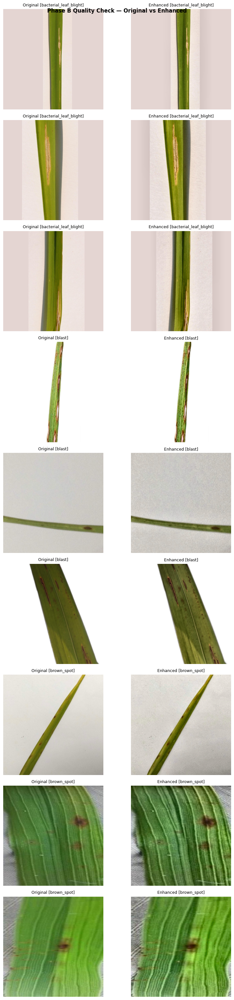


Spot-Check Summary
----------------------------------------
✅ All sampled files loaded successfully
✅ Enhanced images were written correctly
✅ No missing files detected

📁 Enhanced dataset location:
   /content/enhanced_dataset

✅ Phase B preprocessing verification complete


In [14]:
print("=" * 60)
print("  Quality Spot-Check — Reading Back Saved Files")
print("=" * 60)

spot_sample = (
    master[master['status'] == 'processed']
    .groupby('class')
    .apply(
        lambda g: g.sample(
            min(3, len(g)),
            random_state=99
        )
    )
    .reset_index(drop=True)
)

fig, axes = plt.subplots(
    len(spot_sample),
    2,
    figsize=(9, 3.5 * len(spot_sample))
)

corrupt_count = 0

for i, row in spot_sample.iterrows():

    # Original image
    original = cv2.imread(row['path'])

    # Enhanced image
    saved_path = os.path.join(
        ENHANCED_PATH,
        row['class'],
        row['file']
    )

    saved = cv2.imread(saved_path)

    axes[i, 0].imshow(
        cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    )
    axes[i, 0].set_title(
        f"Original [{row['class']}]",
        fontsize=9
    )
    axes[i, 0].axis('off')

    if saved is None:

        corrupt_count += 1

        axes[i, 1].text(
            0.5,
            0.5,
            '⚠️ CORRUPT / MISSING',
            ha='center',
            va='center',
            color='red',
            fontsize=11
        )

        axes[i, 1].axis('off')

    else:

        axes[i, 1].imshow(
            cv2.cvtColor(saved, cv2.COLOR_BGR2RGB)
        )

        axes[i, 1].set_title(
            f"Enhanced [{row['class']}]",
            fontsize=9
        )

        axes[i, 1].axis('off')

plt.suptitle(
    'Phase B Quality Check — Original vs Enhanced',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print("\nSpot-Check Summary")
print("-" * 40)

if corrupt_count == 0:

    print("✅ All sampled files loaded successfully")
    print("✅ Enhanced images were written correctly")
    print("✅ No missing files detected")

else:

    print(f"❌ Corrupt / missing files found: {corrupt_count}")

print(f"\n📁 Enhanced dataset location:")
print(f"   {ENHANCED_PATH}")

print("\n✅ Phase B preprocessing verification complete")

Final Summary, Logs & Export

In [15]:
print("=" * 60)
print("  PHASE B — FINAL SUMMARY & EXPORT")
print("=" * 60)

# ── Status summary ────────────────────────────────────────────
status_counts = master['status'].value_counts()

print(f"\n  Pipeline outcome:")
for status, count in status_counts.items():
    pct = count / len(master) * 100
    symbol = '✅' if status == 'processed' else '❌'
    print(f"    {symbol}  {status:<30} {count:>6}  ({pct:.1f}%)")

# ── Count total errors correctly ──────────────────────────────
error_total = sum(
    count
    for status, count in status_counts.items()
    if str(status).startswith('error')
)

# ── Per-class breakdown ───────────────────────────────────────
print(f"\n  Per-class breakdown:")

breakdown = (
    master.groupby(['class', 'status'])
          .size()
          .unstack(fill_value=0)
)

print(breakdown.to_string())

# ── Save audit log ────────────────────────────────────────────
log_csv = os.path.join(
    LOG_PATH,
    'phase_b_processing_log.csv'
)

master.to_csv(
    log_csv,
    index=False
)

print(f"\n  📄 Audit log saved → {log_csv}")

# ── Zip enhanced dataset ──────────────────────────────────────
print("\n  📦 Zipping enhanced dataset...")

zip_name = 'enhanced_dataset'

shutil.make_archive(
    zip_name,
    'zip',
    ENHANCED_PATH
)

zip_path = f'{zip_name}.zip'

size_mb = (
    os.path.getsize(zip_path)
    / (1024 * 1024)
)

print(f"  ✅ {zip_path} — {size_mb:.1f} MB")

# ── Save to Drive ─────────────────────────────────────────────
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:

    drive_dest = f'/content/drive/MyDrive/{zip_path}'

    shutil.copy(
        zip_path,
        drive_dest
    )

    print(f"  ☁️ Saved to Drive → {drive_dest}")

# ── Optional local download ───────────────────────────────────
DOWNLOAD_LOCAL = False   # set True only for small datasets

if DOWNLOAD_LOCAL:

    from google.colab import files

    print("\n  ⬇️ Starting download...")

    files.download(zip_path)

# ── Final checklist ───────────────────────────────────────────
print(f"""
{'=' * 60}
  ✅ Phase B Complete!
{'=' * 60}

  Input  (Phase A output) : {len(master)} images
  Output (enhanced)       : {status_counts.get('processed', 0)} images
  Errors                  : {error_total} images

  Saved to                : {ENHANCED_PATH}
  Zip                     : {zip_path} ({size_mb:.1f} MB)
  Audit log               : {log_csv}

  Pipeline applied:

    1. CLAHE
       • clipLimit    = {CLAHE_CLIP_LIMIT}
       • tileGridSize = {CLAHE_GRID_SIZE}
       • LAB L-channel only

    2. Gaussian Filtering
       • kernel = {GAUSSIAN_KERNEL}
       • artifact smoothing

  Accepted Techniques:
    ✅ CLAHE
    ✅ Gaussian Filtering

  Rejected Techniques:
    ❌ Reinhard Color Normalization
    ❌ GrabCut Background Removal

{'=' * 60}
""")

  PHASE B — FINAL SUMMARY & EXPORT

  Pipeline outcome:
    ✅  processed                        5230  (100.0%)

  Per-class breakdown:
status                 processed
class                           
bacterial_leaf_blight       1078
blast                       2760
brown_spot                  1392

  📄 Audit log saved → /content/phase_b_logs/phase_b_processing_log.csv

  📦 Zipping enhanced dataset...
  ✅ enhanced_dataset.zip — 2006.5 MB
  ☁️ Saved to Drive → /content/drive/MyDrive/enhanced_dataset.zip

  ✅ Phase B Complete!

  Input  (Phase A output) : 5230 images
  Output (enhanced)       : 5230 images
  Errors                  : 0 images

  Saved to                : /content/enhanced_dataset
  Zip                     : enhanced_dataset.zip (2006.5 MB)
  Audit log               : /content/phase_b_logs/phase_b_processing_log.csv

  Pipeline applied:

    1. CLAHE
       • clipLimit    = 1.8
       • tileGridSize = (8, 8)
       • LAB L-channel only

    2. Gaussian Filtering
       • 